In [1]:
import os
import sys
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from tqdm import tqdm

print(jax.devices())

import importlib
try:
    importlib.reload(sys.modules["src_renyi"])
except KeyError: 
    pass
from src_renyi import (
    ARNN_Z2, RBM_Z2,
    free_energy_minimize_SR_SGD,
    free_energy_minimize,
    free_energy_minimize_scipy,
)

[CudaDevice(id=0)]


In [2]:
# Hilbert space
from netket.hilbert import Spin
N = 2
N_ancilla = N
partition = list(range(N))

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

In [ ]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=2**15)

n_steps = 300
lr = optax.linear_schedule(0.05, 0.005, n_steps)
optimizer = optax.sign_sgd(lr)
sr = nk.optimizer.SR(diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps))
T = 1.8
_,f_best,E_best,S_best = free_energy_minimize(vstate, T, partition, H_extended, n_steps, freq=20,
                                               optimizer=optimizer, learning_rate=lr, clip_norm=None, timing=True,
                                               chunk_size=vstate.n_samples//2, sr=None, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

Total puntos: 56


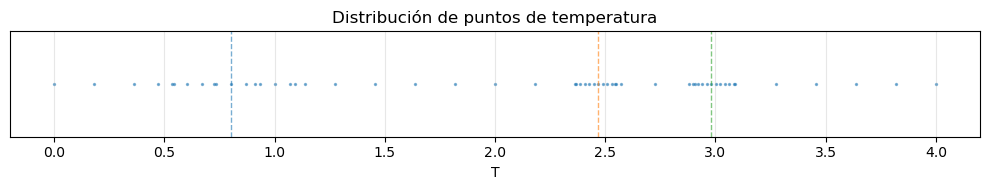

In [9]:
#Choose T array point density
def compute_jump_temperatures(evals, max_jumps=None, tol=1e-10):
    # Colapsar niveles degenerados
    unique_evals = []
    for e in evals:
        if len(unique_evals) == 0 or abs(e - unique_evals[-1]) > tol:
            unique_evals.append(e)
    unique_evals = np.array(unique_evals)
    
    n_levels = len(unique_evals) if max_jumps is None else min(max_jumps + 1, len(unique_evals))
    T_jumps = []
    for n in range(1, n_levels):
        weights = unique_evals[n] - unique_evals[:n]
        E_bar = np.dot(unique_evals[:n], weights) / weights.sum()
        T_jumps.append((unique_evals[n] - E_bar) / 2)
    return np.array(T_jumps)

def make_optimal_T_array(T_jumps, T_min=0.05, T_max=4.0, n_total=200, width_factor=0.1):
    """
    Crea un array de temperaturas con alta densidad cerca de cada T_n.
    
    - Empieza con una malla base uniforme gruesa
    - Añade puntos extra concentrados alrededor de cada T_n con una
      ventana gaussiana de anchura width_factor * gap_local
    """
    # Malla base uniforme (1/3 de los puntos)
    n_base = n_total // 3
    T_base = np.linspace(T_min, T_max, n_base)
    
    # Puntos extra alrededor de cada salto
    T_extra = []
    jumps_in_range = T_jumps[(T_jumps > T_min) & (T_jumps < T_max)]
    
    # Anchura local = fracción del gap al salto más cercano
    for i, Tn in enumerate(jumps_in_range):
        gaps = np.abs(jumps_in_range - Tn)
        gaps = gaps[gaps > 1e-10]  # excluir el propio Tn
        local_gap = gaps.min() if len(gaps) > 0 else (T_max - T_min) / len(jumps_in_range)
        width = width_factor * local_gap
        
        n_local = n_total // (2 * len(jumps_in_range))  # repartir el resto entre saltos
        T_extra.append(np.linspace(Tn - 2*width, Tn + 2*width, n_local))
    
    # Unir, ordenar y eliminar duplicados
    T_all = np.concatenate([T_base] + T_extra)
    T_all = np.clip(T_all, T_min, T_max)
    T_all = np.unique(np.round(T_all, 8))  # elimina duplicados numéricos
    
    return T_all

eigvals, _ = np.linalg.eigh(H_system.to_dense())
T_jumps = compute_jump_temperatures(eigvals)
temperatures = make_optimal_T_array(T_jumps, T_min=0.0, T_max=4.0, n_total=70)
T_jumps_visible = T_jumps[T_jumps <= temperatures[-1]]

print(f"Total puntos: {len(temperatures)}")

# Visualizar la distribución
plt.figure(figsize=(10, 2))
plt.scatter(temperatures, np.zeros_like(temperatures), s=2, alpha=0.5)
cmap = plt.cm.tab10
for i, Tn in enumerate(T_jumps_visible):
    plt.axvline(Tn, color=cmap(i % 10), lw=1, ls='--', alpha=0.6)
plt.xlabel('T'); plt.title('Distribución de puntos de temperatura')
plt.yticks([]); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=2**16)

T_array = np.linspace(0, 4, 41)
n_steps = 330
lr = optax.linear_schedule(0.05, 0.005, n_steps)
optimizer = optax.sign_sgd(lr)
save = False

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None
os.makedirs(f"../data/N{N}/params", exist_ok=True)

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
  
    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot = False,
        optimizer=optimizer,
        chunk_size=vstate.n_samples//2
    )
    best_params = vstate.parameters

    filename = f"../data/N{N}/params/params_{T_idx:04d}.msgpack"
    if save:
        with open(filename, "wb") as f:
            f.write(serialization.to_bytes(best_params))

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if save:
    os.makedirs(f"../data/N{N}", exist_ok=True)
    data = {
        "T":           [float(T) for T in T_array],
        "energy":      [float(x) for x in energy_results],
        "entropy":     [float(x) for x in entropy_results],
        "free_energy": [float(x) for x in free_energy_results],
        "param_index": list(range(len(T_array))),
    }
    with open(f"../data/N{N}/results_N{N}_vs_T.json", "w") as f:
        json.dump(data, f, indent=2)

Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 4, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ── Celda: T_crit analíticos + plot conjunto ──────────────────────────────────

def compute_jump_temperatures(H_phys, max_jumps=None):
    """
    Diagonaliza el Hamiltoniano físico y calcula las temperaturas de salto
    T_n = (1/2) * (E_n - weighted_mean(E_0..E_{n-1}, weights=E_n-E_k))
    
    Devuelve (eigenvalues, jump_temperatures).
    """
    evals = np.linalg.eigvalsh(H_phys.to_dense())   # ya ordenados
    evals = np.sort(evals)
    
    n_levels = len(evals) if max_jumps is None else min(max_jumps + 1, len(evals))
    
    T_jumps = []
    for n in range(1, n_levels):
        En = evals[n]
        prev = evals[:n]
        weights = En - prev            # > 0 por construcción
        E_bar = np.dot(prev, weights) / weights.sum()
        T_n = (En - E_bar) / 2
        T_jumps.append(T_n)
    
    return evals, np.array(T_jumps)


# ── Calcula los saltos usando solo el Hamiltoniano físico (sin ancillas) ───────
H_phys = H_system   # tu Hamiltoniano físico nk.operator, antes de extender con ancillas
evals, T_jumps = compute_jump_temperatures(H_phys, max_jumps=8)

print("Autoenergías (primeras 10):", np.round(evals[:10], 4))
print("Temperaturas de salto:")
for i, Tn in enumerate(T_jumps):
    print(f"  T_{i+1} = {Tn:.4f}   (entra nivel E_{i+1} = {evals[i+1]:.4f})")


# ── Plot conjunto ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# paleta para los saltos
cmap   = plt.cm.tab10
T_max  = max(T_array_scipy[-1], T_array[-1])
T_jumps_visible = T_jumps[T_jumps <= T_max]

def add_jump_lines(ax, label_first=True):
    for i, Tn in enumerate(T_jumps_visible):
        ax.axvline(Tn, color=cmap(i), lw=1.2, ls='--', alpha=0.8,
                   label=f'$T_{{{i+1}}}={Tn:.2f}$' if label_first else None)

# — Energía —
ax = axes[0]
ax.plot(T_array_scipy, energy_results_scipy, '-',  color='C0', label='Scipy (exact)')
ax.plot(T_array,       energy_results,       'o--', color='C1', ms=4, label='VMC')
add_jump_lines(ax, label_first=True)
ax.set_xlabel('T'); ax.set_ylabel(r'$\langle H \rangle$')
ax.set_title('Energía vs T'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)

# — Entropía —
ax = axes[1]
ax.plot(T_array_scipy, entropy_results_scipy, '-',  color='C0', label='Scipy (exact)')
ax.plot(T_array,       entropy_results,       's--', color='C1', ms=4, label='VMC')
add_jump_lines(ax, label_first=False)
ax.set_xlabel('T'); ax.set_ylabel(r'$S_2$')
ax.set_title('Entropía Rényi-2 vs T'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)

# — Energía libre —
ax = axes[2]
ax.plot(T_array_scipy, free_energy_results_scipy, '-',  color='C0', label='Scipy (exact)')
ax.plot(T_array,       free_energy_results,       'd--', color='C1', ms=4, label='VMC')
add_jump_lines(ax, label_first=False)
ax.set_xlabel('T'); ax.set_ylabel(r'$F$')
ax.set_title('Energía Libre vs T'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)

plt.suptitle(f'N={N}  —  Rényi ensemble vs temperatura', fontsize=12)
plt.tight_layout()
plt.savefig(f"../data/N{N}/results_N{N}_combined.pdf", bbox_inches='tight')
plt.show()

# — Tabla resumen —
print("\n── Resumen saltos ──────────────────────────────")
print(f"{'n':>3}  {'E_n':>10}  {'T_n':>10}  {'ΔE_n':>10}")
print("-" * 38)
for i, Tn in enumerate(T_jumps_visible):
    gap = evals[i+1] - evals[i]
    print(f"{i+1:>3}  {evals[i+1]:>10.4f}  {Tn:>10.4f}  {gap:>10.4f}")